# 01 — Data Pipeline

**Pipeline stage 1 of 7.** Load the raw weekly red-tide dataset, engineer features,
split chronologically into train/val/test, scale, and build the LSTM input sequences.

**Inputs**
- `data_weekly_intepolated.csv` (raw weekly observations)
- `shared_config.py` (configuration constants)

**Outputs** (written to `output_refactored/intermediate/`)
- `train_df_unscaled.parquet`, `val_df_unscaled.parquet`, `test_df_unscaled.parquet`
  — chronological splits before scaling (needed downstream for EnKF observations,
  inverse-transforms, and human-readable plots)
- `train_scaled.parquet`, `val_scaled.parquet`, `test_scaled.parquet` — scaled splits
- `sequences_horizon{H}wk_{suffix}.npz` — LSTM-ready 3D arrays
- `red_tide_scaler_*.joblib`, `red_tide_feature_list_*.joblib`

**Downstream notebooks consume these artifacts via `from shared_config import *` plus
`np.load(...)` / `pd.read_parquet(...)`.**

> Source: Parts 1–7 of the original monolithic notebook.


## Setup

In [15]:
# Install scientific stack (run once per environment)
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Project configuration — defines paths, flags, parameters
from shared_config import *
print_config_summary()

--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
EnKF Propagator:               SeasonalAR1
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Part 2: Data Loading & Initial Processing

This cell defines and executes a function to load the raw weekly data, handle the datetime index, calculate U/V wind components, and create the binary target variable based on the bloom threshold. It uses the configuration parameters defined in Part 1.


Explanation:

1. calculate_wind_components(df): Takes a DataFrame, calculates U and V wind components if 'wind_direction' and 'wind_speed' exist, drops the original columns, and returns the modified DataFrame and a list of the newly added column names. Includes basic NaN handling for the calculation.
2. create_target(...): Takes the DataFrame and target configuration, ensures the original target column is numeric, drops rows where the target is NaN (important for supervised learning), creates the binary bloom_target column, prints the class distribution, and returns the DataFrame.
3. load_and_prepare_data(...): Orchestrates the initial steps: loads the CSV, sets the datetime index, calls calculate_wind_components, calls create_target, and returns the resulting DataFrame (df_initial). Includes error handling for file not found or missing columns.
4. merge_external_data(...) (Optional Placeholder): Provides a structure for loading and merging additional datasets based on a dictionary of file paths. It performs a left merge to keep all original data points. Note: This function needs actual file paths and assumes external CSVs have a compatible datetime index.
5. Main Execution Block (if __name__ == "__main__":): Calls load_and_prepare_data using the configuration variables. Includes a commented-out section showing how merge_external_data would be called if needed. Prints final info about the df_initial DataFrame. Includes basic NameError handling in case Part 1 wasn't run.

After running this cell, the df_initial DataFrame should contain the core data with wind components calculated and the binary bloom target created, ready for the feature engineering steps in Part 3.

In [17]:
from lstm_utils import create_sequences_from_df

def calculate_wind_components(df):
    """Calculates U and V wind components if columns exist."""
    if 'wind_direction' in df.columns and 'wind_speed' in df.columns:
        print("Calculating wind U/V components...")
        # Ensure numeric types, handle potential NaNs before calculation
        df['wind_direction'] = pd.to_numeric(df['wind_direction'], errors='coerce')
        df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

        # Temporarily fill NaNs with 0 for calculation if they exist
        wind_cols_to_check = ['wind_direction', 'wind_speed']
        if df[wind_cols_to_check].isnull().any().any():
            print("Warning: NaNs found in wind direction/speed. Temporarily filling with 0 for component calculation.")
            df[wind_cols_to_check] = df[wind_cols_to_check].fillna(0)

        wind_dir_rad = np.deg2rad(df['wind_direction'])
        wind_speed = df['wind_speed']
        # Meteorological convention: wind direction 'coming from'
        df['wind_u'] = -wind_speed * np.sin(wind_dir_rad)
        df['wind_v'] = -wind_speed * np.cos(wind_dir_rad)
        # Drop original wind columns
        df = df.drop(columns=['wind_direction', 'wind_speed'])
        print("Calculated wind U/V components and dropped original columns.")
        added_cols = ['wind_u', 'wind_v']
    else:
        print("Warning: 'wind_direction' or 'wind_speed' not found. Skipping component calculation.")
        added_cols = []
    return df, added_cols

def create_target(df, target_col, bloom_threshold, target_binary_col):
    """Creates the binary target variable."""
    if target_col not in df.columns:
        print(f"Error: Target column '{target_col}' not found.")
        return None # Return None if target column is missing

    print(f"Creating binary target '{target_binary_col}' using threshold {bloom_threshold:.0f} cells/L...")
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Handle potential NaNs in target before comparison by dropping rows
    initial_rows = len(df)
    if df[target_col].isnull().any():
        print(f"Warning: NaNs found in target column '{target_col}'. Dropping rows with NaN target.")
        df.dropna(subset=[target_col], inplace=True)
        print(f"Dropped {initial_rows - len(df)} rows with NaN in '{target_col}'. New shape: {df.shape}")

    df[target_binary_col] = (df[target_col] >= bloom_threshold).astype(int)
    print(f"Target distribution (%):\n{df[target_binary_col].value_counts(normalize=True) * 100}")
    return df

def load_and_prepare_data(filepath, datetime_col, target_col, bloom_threshold, target_binary_col):
    """Loads data, handles datetime, calculates wind components, creates target."""
    print(f"Loading data from: {filepath}")
    try:
        df = pd.read_csv(filepath)
        # Handle datetime index
        if datetime_col not in df.columns:
            raise ValueError(f"Datetime column '{datetime_col}' not found.")
        df[datetime_col] = pd.to_datetime(df[datetime_col])
        df = df.sort_values(datetime_col).set_index(datetime_col)
        print(f"Data loaded successfully. Shape: {df.shape}, Time range: {df.index.min()} to {df.index.max()}")
        print(f"Initial NaN counts:\n{df.isnull().sum()}")

        # Calculate wind components
        df, wind_cols = calculate_wind_components(df)

        # Create binary target
        df = create_target(df, target_col, bloom_threshold, target_binary_col)

        if df is not None:
            print("\n--- Initial Data Preparation Complete ---")
            print(f"DataFrame shape after initial processing: {df.shape}")
            print("Columns:", df.columns.tolist())
            print("\nFirst 5 rows:")
            print(df.head())
        return df

    except FileNotFoundError:
        print(f"Error: Input data file not found at {filepath}")
        return None
    except ValueError as ve:
        print(f"ValueError during data preparation: {ve}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during data loading/preparation: {e}")
        return None

# --- Optional: Function Placeholder for Merging External Data ---
def merge_external_data(df, external_files_dict):
    """
    Loads and merges external data (e.g., Caloosahatchee Q/NOx) into the main dataframe.
    Args:
        df (pd.DataFrame): The main dataframe with datetime index.
        external_files_dict (dict): Dictionary where keys are column names (e.g., 'caloos_Q')
                                     and values are file paths to the external CSV data.
                                     External CSVs must have a compatible datetime index.
    Returns:
        pd.DataFrame: DataFrame with external data merged (left join).
    """
    print("\n--- Merging External Data (Placeholder) ---")
    if not external_files_dict:
        print("No external data files specified.")
        return df

    df_merged = df.copy()
    for col_name, file_path in external_files_dict.items():
        try:
            print(f"Loading external data for '{col_name}' from '{file_path}'...")
            # Assuming external CSV has datetime index named same as DATETIME_COL or is the index
            df_ext = pd.read_csv(file_path, index_col=DATETIME_COL, parse_dates=True) # Adjust index_col if needed
            df_ext = df_ext[[col_name]] # Keep only the specified column
            # Perform left merge
            df_merged = df_merged.merge(df_ext, left_index=True, right_index=True, how='left')
            print(f"Merged '{col_name}'. NaN count: {df_merged[col_name].isnull().sum()}")
        except FileNotFoundError:
            print(f"Warning: External data file not found: {file_path}. Skipping '{col_name}'.")
        except KeyError:
             print(f"Warning: Column '{col_name}' not found in file {file_path}. Skipping.")
        except Exception as e:
            print(f"Error merging external file {file_path}: {e}")

    print("External data merging complete.")
    return df_merged


# --- Execute Data Loading and Preparation ---
# Ensure config variables from Part 1 are defined before running this
if __name__ == "__main__":
    try:
        df_initial = load_and_prepare_data(
            INPUT_DATA_PATH,
            DATETIME_COL,
            TARGET_COL,
            BLOOM_THRESHOLD,
            TARGET_BINARY_COL
        )

        if df_initial is not None:
            # Display basic info about the prepared dataframe
            print("\n--- Dataframe after initial processing (df_initial) ---")
            df_initial.info()
        else:
            print("\nData loading/preparation failed.")

    except NameError as ne:
         print(f"NameError: A configuration variable might be missing. Did Part 1 run correctly? Error: {ne}")
    except Exception as e:
         print(f"An unexpected error occurred in main execution block: {e}")



Loading data from: data_weekly_intepolated.csv
Data loaded successfully. Shape: (1617, 9), Time range: 1993-01-04 00:00:00 to 2023-12-25 00:00:00
Initial NaN counts:
kb                 0
zos                0
salinity           0
water_temp         0
wind_direction     0
wind_speed         0
peace_discharge    0
peace_TN           0
peace_TP           0
dtype: int64
Calculating wind U/V components...
Calculated wind U/V components and dropped original columns.
Creating binary target 'bloom_target' using threshold 100000 cells/L...
Target distribution (%):
bloom_target
0    73.09833
1    26.90167
Name: proportion, dtype: float64

--- Initial Data Preparation Complete ---
DataFrame shape after initial processing: (1617, 10)
Columns: ['kb', 'zos', 'salinity', 'water_temp', 'peace_discharge', 'peace_TN', 'peace_TP', 'wind_u', 'wind_v', 'bloom_target']

First 5 rows:
               kb       zos   salinity  water_temp  peace_discharge  peace_TN  \
time                                         

In [18]:
# --- Part 2b: Raw-branch guardrail ---
# Do not mutate df_initial here. The standalone/raw branch must remain raw;
# the explicit EnKF branch is built later in the artifact-persistence block
# and writes ENKF_* artifacts separately.
df_initial_raw = df_initial.copy() if df_initial is not None else None
print("Raw df_initial preserved; EnKF preprocessing is deferred to the explicit EnKF branch.")

Raw df_initial preserved; EnKF preprocessing is deferred to the explicit EnKF branch.


## Part 3: Feature Engineering

This part defines and executes a function create_features that adds lagged features to the initially processed DataFrame (df_initial from Part 2). It uses the configuration flags set in Part 1 (USE_ENHANCED_FEATURES) to determine whether to create basic lags or the more detailed lags inspired by the Random Forest paper.

This cell defines the feature engineering function and applies it to the df_initial DataFrame. It creates lagged versions of environmental variables and, optionally, more detailed lagged and rolling aggregate features for K. brevis counts.

Explanation:

1. Configuration: It first defines or ensures access to the necessary configuration variables from Part 1 (like USE_ENHANCED_FEATURES, lag definitions, feature lists).
2. create_features(...) Function:
    - Takes the initial DataFrame (df_initial) and configuration details as input.
    - Selects either BASIC_LAG_CONFIG or ENHANCED_LAG_CONFIG based on the USE_ENHANCED_FEATURES flag.
    - KB Lags: Creates simple weekly lags (_L1, _L2) for the raw kb column.
    - KB Rolling Aggregates (Enhanced Only): Calculates rolling mean (_M1_mean, _M2_mean, etc.) and rolling proportion of bloom weeks (_M1_prop, _M2_prop, etc.) over specified windows (e.g., 4, 8, 12 weeks), shifted back appropriately.
    - Discharge Rolling Average (Enhanced Only): Calculates a rolling average (e.g., 4-week) for the primary discharge column, lagged by 1 week.
    - Environmental Lags: Creates simple weekly lags for all other specified environmental/hydrological variables (BASE_FEATURES). The number of lags depends on whether basic or enhanced mode is selected.
    - NaN Handling: Tracks the maximum lag introduced by any operation and drops the corresponding number of initial rows from the DataFrame to ensure sequences are complete.
    - All-NaN Column Check: Includes a check to identify and optionally drop columns that might become entirely NaN after lagging (important for sparse data).
    - Returns the final DataFrame (df_processed) with all engineered features.

3. Main Execution: Calls the create_features function with the appropriate arguments based on the configuration flags. Prints the head and tail of the resulting df_processed DataFrame.

After running this cell, df_processed will contain the data ready for splitting (Part 4) and subsequent preprocessing/modeling steps. The number of columns will vary depending on whether basic or enhanced features were generated.

In [19]:
# --- Configuration (Ensure these are defined from Part 1 or redefined here) ---
TARGET_COL = 'kb'
TARGET_BINARY_COL = 'bloom_target'
USE_ENHANCED_FEATURES = True # Set based on Part 1 config

# Define lag configurations (can be pulled from Part 1 config)
BASIC_LAG_CONFIG = {
    'kb_lags': [1, 2],
    'env_lags': list(range(1, 7))
}
ENHANCED_LAG_CONFIG = {
    'kb_lags': [1, 2],
    'kb_rolling_windows': [(1, 4), (5, 8), (9, 12)], # (start_lag, end_lag)
    'discharge_rolling_window': 4, # Window size for rolling avg discharge
    'env_lags': [1] # Lags for other env vars in enhanced mode
}
# Features to lag (environmental/hydrological) - should include wind components if created
BASE_FEATURES = [
    'zos', 'water_temp',
    'peace_discharge', 'peace_TN', 'peace_TP',
    'wind_u', 'wind_v','wind_alongshore'
]

In [20]:
# --- Onset-relevant feature additions (run before create_features) ---
# These columns get appended to df_initial so the existing lag/rolling
# machinery in create_features() picks them up the same way it does the
# original drivers.

import onset_utils as ou

if df_initial is not None:
    # 1) Alongshore wind projection — upwelling proxy for the WFS shelf.
    if {"wind_u", "wind_v"}.issubset(df_initial.columns):
        df_initial["wind_alongshore"] = ou.alongshore_wind(
            df_initial["wind_u"], df_initial["wind_v"],
            shelf_angle_deg=340.0,
        )
        print("Added: wind_alongshore")

    # 2) Rate-of-change features on key drivers. These capture the *shift*
    #    in conditions that precedes an onset rather than the absolute level.
    df_initial = ou.add_rate_of_change_features(
        df_initial,
        cols=["water_temp", "peace_TN", "peace_TP",
              "peace_discharge", "zos"],
        windows=(2, 4, 8),
        suffix="d",
    )
    print("Added: rate-of-change features for "
          "water_temp/peace_TN/peace_TP/peace_discharge/zos (windows 2/4/8 wk)")

    # 3) Cumulative driver anomalies vs. a 52-week climatology.
    #    NOTE: this uses the full series for climatology estimation. For
    #    strict causality on the test set, recompute climatology from the
    #    training slice only and broadcast. Document this in the methods.
    df_initial = ou.add_cumulative_anomaly_features(
        df_initial,
        cols=["water_temp", "peace_TN", "peace_TP"],
        climatology_period=52,
        accumulation_windows=(4, 8, 12),
    )
    print("Added: cumulative-anomaly features for "
          "water_temp/peace_TN/peace_TP (windows 4/8/12 wk)")

    # 4) Weeks since the most recent bloom — priming-state feature.
    #    Built from the bloom target column. Not strictly leakage because
    #    operationally you have this info, but document in methods.
    if TARGET_BINARY_COL in df_initial.columns:
        wsb = ou.weeks_since_last_bloom(df_initial[TARGET_BINARY_COL])
        # Replace the leading-window NaNs with a sentinel large value.
        wsb = pd.Series(wsb, index=df_initial.index)
        wsb = wsb.fillna(wsb.max() if wsb.notna().any() else 0)
        df_initial["weeks_since_bloom"] = wsb
        print("Added: weeks_since_bloom")

    print(f"\ndf_initial shape after onset features: {df_initial.shape}")
else:
    print("Skipping onset feature additions: df_initial is None.")

Added: wind_alongshore
Added: rate-of-change features for water_temp/peace_TN/peace_TP/peace_discharge/zos (windows 2/4/8 wk)
Added: cumulative-anomaly features for water_temp/peace_TN/peace_TP (windows 4/8/12 wk)
Added: weeks_since_bloom

df_initial shape after onset features: (1617, 36)


In [21]:
# --- Function Definition ---
def create_features(df, target_col, target_binary_col, base_features, use_enhanced=False, basic_cfg=None, enhanced_cfg=None):
    """Creates lagged and rolling features based on configuration."""
    if df is None:
        print("Error in create_features: Input DataFrame is None.")
        return None

    print(f"\n--- Creating Features (Enhanced Mode: {use_enhanced}) ---")
    df_featured = df.copy()
    all_created_feature_cols = list(df.columns) # Start with existing columns

    # Select config based on flag
    if use_enhanced:
        cfg = enhanced_cfg if enhanced_cfg else ENHANCED_LAG_CONFIG
        env_lags = cfg.get('env_lags', [1])
        kb_lags = cfg.get('kb_lags', [])
        kb_rolling_windows = cfg.get('kb_rolling_windows', [])
        discharge_rolling_window = cfg.get('discharge_rolling_window', None)
        print("Using ENHANCED feature configuration.")
    else:
        cfg = basic_cfg if basic_cfg else BASIC_LAG_CONFIG
        env_lags = cfg.get('env_lags', [])
        kb_lags = cfg.get('kb_lags', [])
        kb_rolling_windows = [] # No rolling features in basic mode
        discharge_rolling_window = None
        print("Using BASIC feature configuration.")

    max_lag_needed = 0 # Track the maximum lag introduced

    # --- Lagged K. brevis Features (Raw Counts) ---
    if target_col in df.columns and kb_lags:
        print(f"Creating lagged features for target: {target_col}...")
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        for lag in kb_lags:
            col_name = f'{target_col}_L{lag}'
            df_featured[col_name] = df[target_col].shift(lag)
            all_created_feature_cols.append(col_name)
            max_lag_needed = max(max_lag_needed, lag)
        print(f"  Created KB weekly lags: L{', L'.join(map(str, kb_lags))}")
    elif kb_lags:
        print(f"Warning: Target column '{target_col}' not found for lagging.")

    # --- Rolling K. brevis Features (Enhanced Mode Only) ---
    if use_enhanced and kb_rolling_windows and target_col in df.columns and target_binary_col in df.columns:
        print("Creating rolling aggregate features for KB...")
        target_binary_1e5 = df[target_binary_col]
        monthly_lags_created = []
        max_roll_lag = 0
        for i, (start_lag, end_lag) in enumerate(kb_rolling_windows):
            window_size = end_lag - start_lag + 1
            month_lag_id = f'M{i+1}'
            monthly_lags_created.append(month_lag_id)
            max_roll_lag = max(max_roll_lag, end_lag) # Max lag needed for rolling window

            # Mean of raw kb over the window, shifted back
            col_name_mean = f'{target_col}_{month_lag_id}_mean'
            df_featured[col_name_mean] = df[target_col].rolling(window=window_size, min_periods=1).mean().shift(start_lag)
            all_created_feature_cols.append(col_name_mean)

            # Proportion of bloom weeks (target=1) over the window, shifted back
            col_name_prop = f'{target_binary_col}_{month_lag_id}_prop'
            df_featured[col_name_prop] = target_binary_1e5.rolling(window=window_size, min_periods=1).mean().shift(start_lag)
            all_created_feature_cols.append(col_name_prop)
        print(f"  Created approx KB monthly lags (mean, prop_bloom): {', '.join(monthly_lags_created)}")
        max_lag_needed = max(max_lag_needed, max_roll_lag) # Rolling needs lookback up to end_lag

    # --- Rolling Discharge Feature (Enhanced Mode Only) ---
    discharge_col = 'peace_discharge' # Or potentially 'caloos_Q' if prioritized/available
    if use_enhanced and discharge_rolling_window and discharge_col in df.columns:
         print(f"Creating rolling average feature for {discharge_col}...")
         window_size = discharge_rolling_window
         # Typically want average over past month, lagged by 1 week
         start_lag = 1
         col_name_discharge_roll = f'{discharge_col}_{window_size}w_avg_L{start_lag}'
         df_featured[col_name_discharge_roll] = df[discharge_col].rolling(window=window_size, min_periods=1).mean().shift(start_lag)
         all_created_feature_cols.append(col_name_discharge_roll)
         max_lag_needed = max(max_lag_needed, window_size + start_lag -1) # Max lookback needed
         print(f"  Created {col_name_discharge_roll}")


    # --- Lagged Environmental/Hydrological Features ---
    if env_lags:
        print("\nCreating lagged environmental/hydrological features...")
        lagged_env_cols_added_names = []
        max_env_lag = 0
        for feature in base_features:
             if feature in df.columns:
                df[feature] = pd.to_numeric(df[feature], errors='coerce') # Ensure numeric
                for lag in env_lags:
                    col_name = f'{feature}_L{lag}'
                    df_featured[col_name] = df[feature].shift(lag)
                    all_created_feature_cols.append(col_name)
                    max_env_lag = max(max_env_lag, lag)
                lagged_env_cols_added_names.append(feature)
             else:
                print(f"  Warning: Feature '{feature}' not found for lagging.")
        if lagged_env_cols_added_names:
            print(f"  Lagged features created for: {', '.join(lagged_env_cols_added_names)} using lags L{', L'.join(map(str, env_lags))}")
        max_lag_needed = max(max_lag_needed, max_env_lag)

    # --- Drop Rows with NaNs from Lagging/Rolling ---
    print(f"\nMaximum lag/window introduced: {max_lag_needed} weeks.")
    initial_rows = len(df_featured)
    if max_lag_needed > 0:
        df_processed = df_featured.iloc[max_lag_needed:].copy()
        print(f"Dropped first {max_lag_needed} rows due to NaNs generated by feature engineering.")
        print(f"Shape after dropping initial NaNs: {df_processed.shape}")
    else:
        df_processed = df_featured.copy()
        print("No lagging applied or max lag was 0, no initial rows dropped.")

    # Final check for all-NaN columns (can happen with rolling/shifting if data is sparse)
    all_nan_cols = df_processed.columns[df_processed.isnull().all()].tolist()
    if all_nan_cols:
        print(f"\nWarning: The following columns consist entirely of NaNs and will be dropped: {all_nan_cols}")
        df_processed = df_processed.dropna(axis=1, how='all')
        print(f"Shape after dropping all-NaN columns: {df_processed.shape}")

    # Ensure no duplicate columns (though unlikely with this structure)
    df_processed = df_processed.loc[:,~df_processed.columns.duplicated()]

    print("\n--- Feature Engineering Complete ---")
    print(f"Final number of columns (features + targets): {len(df_processed.columns)}")
    return df_processed

# --- Execute Feature Engineering ---
# Ensure df_initial exists from Part 2 and config variables from Part 1
if __name__ == "__main__":
    try:
        if 'df_initial' in locals() and df_initial is not None:
            # Determine which config to use based on the flag from Part 1
            lag_config_to_use = ENHANCED_LAG_CONFIG if USE_ENHANCED_FEATURES else BASIC_LAG_CONFIG
            features_to_lag_list = BASE_FEATURES # Modify if external data was added

            df_processed = create_features(
                df_initial,
                TARGET_COL,
                TARGET_BINARY_COL,
                features_to_lag_list,
                use_enhanced=USE_ENHANCED_FEATURES,
                basic_cfg=BASIC_LAG_CONFIG,
                enhanced_cfg=ENHANCED_LAG_CONFIG
            )

            if df_processed is not None:
                print("\nFirst 5 rows of processed data (df_processed):")
                display(df_processed.head())
                print("\nLast 5 rows:")
                display(df_processed.tail())
                print(f"\nFinal shape of df_processed: {df_processed.shape}")
            else:
                print("\nFeature engineering failed.")
        else:
            print("\nError: df_initial not found or is None. Please run Part 2 first.")

    except NameError as ne:
         print(f"NameError: A configuration variable might be missing. Did Part 1 run correctly? Error: {ne}")
    except Exception as e:
         print(f"An unexpected error occurred in main execution block: {e}")




--- Creating Features (Enhanced Mode: True) ---
Using ENHANCED feature configuration.
Creating lagged features for target: kb...
  Created KB weekly lags: L1, L2
Creating rolling aggregate features for KB...
  Created approx KB monthly lags (mean, prop_bloom): M1, M2, M3
Creating rolling average feature for peace_discharge...
  Created peace_discharge_4w_avg_L1

Creating lagged environmental/hydrological features...
  Lagged features created for: zos, water_temp, peace_discharge, peace_TN, peace_TP, wind_u, wind_v, wind_alongshore using lags L1

Maximum lag/window introduced: 12 weeks.
Dropped first 12 rows due to NaNs generated by feature engineering.
Shape after dropping initial NaNs: (1605, 53)

--- Feature Engineering Complete ---
Final number of columns (features + targets): 53

First 5 rows of processed data (df_processed):


,kb,zos,salinity,water_temp,peace_discharge,peace_TN,peace_TP,wind_u,wind_v,bloom_target,...,bloom_target_M3_prop,peace_discharge_4w_avg_L1,zos_L1,water_temp_L1,peace_discharge_L1,peace_TN_L1,peace_TP_L1,wind_u_L1,wind_v_L1,wind_alongshore_L1
time,,,,,,,,,,,,,,,,,,,,,
1993-03-29,0.0,-0.060247,33.304348,26.2,2000.0,2.02,1.504000,-11.346331,9.188078,0,...,0.0,1822.5,-0.061417,25.5,2550.0,1.948,1.565333,-17.499440,5.685913,11.328171
1993-04-05,0.0,-0.037195,33.326087,26.4,3290.0,5.68,1.442667,-17.383315,-2.753247,0,...,0.0,2050.0,-0.060247,26.2,2000.0,2.020,1.504000,-11.346331,9.188078,12.514643
1993-04-12,0.0,-0.008214,33.347826,26.3,3140.0,9.34,1.381333,-12.056565,9.419621,0,...,0.0,2600.0,-0.037195,26.4,3290.0,5.680,1.442667,-17.383315,-2.753247,3.358238
1993-04-19,0.0,-0.012612,33.369565,26.5,2040.0,13.00,1.320000,-9.191863,-10.954436,0,...,0.0,2745.0,-0.008214,26.3,3140.0,9.340,1.381333,-12.056565,9.419621,12.975136
1993-04-26,0.0,-0.034968,33.391304,26.9,1800.0,9.30,1.440000,-12.943406,3.468175,0,...,0.0,2617.5,-0.012612,26.5,2040.0,13.000,1.320000,-9.191863,-10.954436,-7.150000



Last 5 rows:


,kb,zos,salinity,water_temp,peace_discharge,peace_TN,peace_TP,wind_u,wind_v,bloom_target,...,bloom_target_M3_prop,peace_discharge_4w_avg_L1,zos_L1,water_temp_L1,peace_discharge_L1,peace_TN_L1,peace_TP_L1,wind_u_L1,wind_v_L1,wind_alongshore_L1
time,,,,,,,,,,,,,,,,,,,,,
2023-11-27,0.0,-0.005114,36.0,27.110714,326.0,2.0675,0.8365,-11.482282,-2.065989,0,...,0.0,496.25,0.022788,27.271429,392.0,1.9550,0.8730,-11.853374,4.605556,8.381899
2023-12-04,0.0,-0.003981,36.0,26.992857,231.0,2.1800,0.8000,-12.302635,0.314994,0,...,0.0,392.25,-0.005114,27.110714,326.0,2.0675,0.8365,-11.482282,-2.065989,1.985777
2023-12-11,0.0,-0.009013,36.0,26.528571,201.0,1.8400,0.7900,-12.016729,-1.298361,0,...,0.0,323.25,-0.003981,26.992857,231.0,2.1800,0.8000,-12.302635,0.314994,4.503746
2023-12-18,0.0,0.005557,36.0,26.207143,460.0,2.2080,0.9700,-11.410499,4.251085,0,...,0.0,287.50,-0.009013,26.528571,201.0,1.8400,0.7900,-12.016729,-1.298361,2.889903
2023-12-25,0.0,0.001243,36.0,26.053571,470.0,2.2080,0.9700,-13.387089,0.506480,0,...,0.0,304.50,0.005557,26.207143,460.0,2.2080,0.9700,-11.410499,4.251085,7.897333



Final shape of df_processed: (1605, 53)


## Part 4: Data Splitting (Chronological)

This part defines and executes a function to split the feature-engineered DataFrame (df_processed from Part 3) into training, validation, and testing sets based on time. A chronological split is essential for time-series data to ensure the model is trained on past data and evaluated on future data, simulating a real-world forecasting scenario.

This cell defines the split_data_chronological function and applies it to df_processed. It uses the TRAIN_SPLIT_RATIO and VALIDATION_SPLIT_RATIO defined in Part 1 to divide the data.

Explanation:
1. Function split_data_chronological:
    - Takes the feature-engineered DataFrame (df_processed) and the desired train/validation ratios as input.
    - Includes checks to ensure the input DataFrame is valid and has a datetime index.
    - Calculates the number of samples for each set based on the ratios.
    - Performs the split using integer-location based indexing (iloc) which respects the chronological order. .copy() is used to avoid potential SettingWithCopyWarning later.
    - Prints the size and date range of each resulting subset.
    - Includes an assertion to double-check that the splits don't overlap.
    - Returns the three DataFrames: train_df, validation_df, test_df.

2. Main Execution:
    - Calls the function using df_processed (output of Part 3) and the ratios defined in the configuration (Part 1).
    - Stores the results in train_df, validation_df, and test_df. These variables will be used in subsequent steps (scaling, sequence creation, EnKF).
    - Prints the head of train_df for verification.

After running this cell, you will have the data divided into the necessary subsets for training, validation (tuning/early stopping), and final testing, while preserving the temporal order. The next step (Part 5) will handle imputation and scaling, fitting the necessary objects only on train_df.

In [22]:
# --- Configuration (Ensure these are defined from Part 1 or redefined here) ---
TRAIN_SPLIT_RATIO = 0.70
VALIDATION_SPLIT_RATIO = 0.15
# Test split ratio is implicitly calculated

# --- Function Definition ---
def split_data_chronological(df, train_ratio, val_ratio):
    """
    Splits the DataFrame chronologically into train, validation, and test sets.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index, sorted chronologically.
        train_ratio (float): The proportion of data to use for training (e.g., 0.7).
        val_ratio (float): The proportion of data to use for validation (e.g., 0.15).

    Returns:
        tuple: A tuple containing train_df, validation_df, test_df (pd.DataFrames),
               or (None, None, None) if splitting fails.
    """
    if df is None or df.empty:
        print("Error in split_data_chronological: Input DataFrame is None or empty.")
        return None, None, None
    if not isinstance(df.index, pd.DatetimeIndex):
         print("Error: DataFrame index must be a DatetimeIndex.")
         return None, None, None
    if not df.index.is_monotonic_increasing:
         print("Warning: DataFrame index is not sorted chronologically. Sorting now...")
         df = df.sort_index()

    print("\n--- Splitting Data into Train, Validation, and Test Sets (Chronological) ---")
    n_total = len(df)
    n_train = int(n_total * train_ratio)
    n_validation = int(n_total * val_ratio)
    n_test = n_total - n_train - n_validation

    # Ensure calculated splits are valid
    if n_train <= 0 or n_validation <= 0 or n_test <= 0:
         print(f"Error: Not enough data ({n_total} rows) to create non-empty train/validation/test splits.")
         print(f"Calculated splits: Train={n_train}, Val={n_validation}, Test={n_test}")
         return None, None, None
    if n_train + n_validation + n_test != n_total:
         print("Error: Split ratios do not sum correctly.")
         return None, None, None

    # Perform chronological split using iloc
    train_df = df.iloc[:n_train].copy()
    validation_df = df.iloc[n_train : n_train + n_validation].copy()
    test_df = df.iloc[n_train + n_validation :].copy() # Takes the rest

    print(f"Total samples: {n_total}")
    print(f"Training set:   {len(train_df)} samples (Index: {train_df.index.min()} to {train_df.index.max()})")
    print(f"Validation set: {len(validation_df)} samples (Index: {validation_df.index.min()} to {validation_df.index.max()})")
    print(f"Test set:       {len(test_df)} samples (Index: {test_df.index.min()} to {test_df.index.max()})")

    # Basic check for overlap
    assert train_df.index.max() < validation_df.index.min(), "Train/Validation sets overlap!"
    assert validation_df.index.max() < test_df.index.min(), "Validation/Test sets overlap!"

    print("Data splitting complete.")
    return train_df, validation_df, test_df

# --- Execute Data Splitting ---
# Ensure df_processed exists from Part 3
if __name__ == "__main__":
    try:
        if 'df_processed' in locals() and df_processed is not None:
            # Use ratios defined in Part 1 config
            train_df, validation_df, test_df = split_data_chronological(
                df_processed,
                TRAIN_SPLIT_RATIO,
                VALIDATION_SPLIT_RATIO
            )

            if train_df is not None:
                # Display head of training data as confirmation
                print("\nHead of Training Data (train_df):")
                display(train_df.head())
                # Keep test_df (unscaled) for later use with EnKF
                print("\nUnscaled test_df also created for EnKF observations.")
            else:
                print("\nData splitting failed.")
        else:
            print("\nError: df_processed not found or is None. Please run Part 3 first.")
            # Define placeholders to prevent errors if run out of order in notebook
            train_df, validation_df, test_df = None, None, None

    except NameError as ne:
         print(f"NameError: A configuration variable might be missing. Did Part 1 run correctly? Error: {ne}")
    except Exception as e:
         print(f"An unexpected error occurred in main execution block: {e}")
         train_df, validation_df, test_df = None, None, None




--- Splitting Data into Train, Validation, and Test Sets (Chronological) ---
Total samples: 1605
Training set:   1123 samples (Index: 1993-03-29 00:00:00 to 2014-09-29 00:00:00)
Validation set: 240 samples (Index: 2014-10-06 00:00:00 to 2019-05-06 00:00:00)
Test set:       242 samples (Index: 2019-05-13 00:00:00 to 2023-12-25 00:00:00)
Data splitting complete.

Head of Training Data (train_df):


,kb,zos,salinity,water_temp,peace_discharge,peace_TN,peace_TP,wind_u,wind_v,bloom_target,...,bloom_target_M3_prop,peace_discharge_4w_avg_L1,zos_L1,water_temp_L1,peace_discharge_L1,peace_TN_L1,peace_TP_L1,wind_u_L1,wind_v_L1,wind_alongshore_L1
time,,,,,,,,,,,,,,,,,,,,,
1993-03-29,0.0,-0.060247,33.304348,26.2,2000.0,2.02,1.504000,-11.346331,9.188078,0,...,0.0,1822.5,-0.061417,25.5,2550.0,1.948,1.565333,-17.499440,5.685913,11.328171
1993-04-05,0.0,-0.037195,33.326087,26.4,3290.0,5.68,1.442667,-17.383315,-2.753247,0,...,0.0,2050.0,-0.060247,26.2,2000.0,2.020,1.504000,-11.346331,9.188078,12.514643
1993-04-12,0.0,-0.008214,33.347826,26.3,3140.0,9.34,1.381333,-12.056565,9.419621,0,...,0.0,2600.0,-0.037195,26.4,3290.0,5.680,1.442667,-17.383315,-2.753247,3.358238
1993-04-19,0.0,-0.012612,33.369565,26.5,2040.0,13.00,1.320000,-9.191863,-10.954436,0,...,0.0,2745.0,-0.008214,26.3,3140.0,9.340,1.381333,-12.056565,9.419621,12.975136
1993-04-26,0.0,-0.034968,33.391304,26.9,1800.0,9.30,1.440000,-12.943406,3.468175,0,...,0.0,2617.5,-0.012612,26.5,2040.0,13.000,1.320000,-9.191863,-10.954436,-7.150000



Unscaled test_df also created for EnKF observations.


## Part 5: Preprocessing (Imputation & Scaling)

This step takes the chronologically split dataframes (train_df, validation_df, test_df from Part 4) and performs two crucial preprocessing tasks:

Imputation: Handles any remaining missing values (NaNs) in the feature columns. It's vital to fit the imputer only on the training data.
Scaling: Scales the numerical features using the scaler type specified in the configuration (RobustScaler or StandardScaler). The scaler is fit only on the training data.
The fitted scaler and the final list of feature columns used are saved.

This cell defines the preprocess_data function to handle imputation and scaling, fitting the necessary transformers only on the training set. It then applies this function to the split dataframes generated in Part 4.

Explanation of Fixes:
- feature_suffix Definition: The NameError occurred because feature_suffix (which depends on USE_ENHANCED_FEATURES) was used to construct FEATURE_LIST_FILENAME before the main execution block where it would be defined.
- Solution: The code now defines feature_suffix inside the if __name__ == "__main__": block before calling preprocess_data. Filename templates (scaler_fname_template, flist_fname_template) are passed to the function, and the final filenames are constructed inside the function using the passed feature_suffix.
- Configuration Checks: Added more robust checks at the beginning of the main execution block to ensure all necessary configuration variables and dataframes exist before proceeding.
- Error Handling: Added more specific error messages and try-except blocks within the preprocess_data function for robustness during imputation and scaling transforms.
- Clarity: Minor adjustments to print statements for better clarity.
Now, when you run this corrected Part 5 cell (after ensuring Part 1 and Part 4 have run successfully in your session), it should correctly define feature_suffix, construct the filenames, perform the preprocessing, save the components, and store the results in the train_scaled_df, validation_scaled_df, etc., variables without the NameError.

In [23]:
# --- Part 5: Preprocessing (Imputation & Scaling) ---

def preprocess_data(train_df, validation_df, test_df, target_col, scaler_type='Robust',
                    output_dir='output/', scaler_fname_template=None, flist_fname_template=None, feature_suffix='basic'):

    # 1. Validate Inputs
    if any(df is None or df.empty for df in [train_df, validation_df, test_df]):
        print("Error: One or more input DataFrames are invalid.")
        return (None,) * 5

    print(f"\n--- Preprocessing Data (Imputation & Scaling: {scaler_type}) ---")

    # 2. Identify Features (Exclude Target)
    # We use training data to determine features
    feature_candidates = [c for c in train_df.columns if c != target_col]
    final_feature_columns = train_df[feature_candidates].select_dtypes(include=np.number).columns.tolist()

    if not final_feature_columns:
        print("Error: No numeric features found.")
        return (None,) * 5

    print(f"Identified {len(final_feature_columns)} numeric features.")

    # 3. Initialize Transformers
    imputer = SimpleImputer(strategy='mean')

    if scaler_type.lower() == 'standard':
        scaler = StandardScaler()
    else:
        scaler = RobustScaler() # Default to Robust

    # 4. Fit Transformers (ONLY on Training Data)
    train_proc_df = train_df.copy()

    # Imputation Fit
    impute_needed = train_proc_df[final_feature_columns].isnull().values.any()
    if impute_needed:
        print("Fitting imputer on training data...")
        imputer.fit(train_proc_df[final_feature_columns])
    else:
        print("No missing values in training set. Skipping imputer fitting.")

    # Scaling Fit (Fit on imputed training data)
    # If we imputed, we must transform the temp training data to fit the scaler correctly
    temp_train_features = imputer.transform(train_proc_df[final_feature_columns]) if impute_needed else train_proc_df[final_feature_columns]

    print(f"Fitting {scaler_type}Scaler on training data...")
    scaler.fit(temp_train_features)

    # 5. Transform All Sets (Loop to remove redundancy)
    processed_dfs = []
    datasets = [train_df, validation_df, test_df]
    set_names = ['Train', 'Validation', 'Test']

    for name, df in zip(set_names, datasets):
        df_copy = df.copy()
        try:
            # Apply Imputation
            if impute_needed:
                df_copy[final_feature_columns] = imputer.transform(df_copy[final_feature_columns])

            # Apply Scaling
            df_copy[final_feature_columns] = scaler.transform(df_copy[final_feature_columns])
            processed_dfs.append(df_copy)
        except Exception as e:
            print(f"Error processing {name} set: {e}")
            return (None,) * 5

    train_scaled, val_scaled, test_scaled = processed_dfs
    print("Transformation complete.")

    # 6. Save Components
    try:
        os.makedirs(output_dir, exist_ok=True)
        # Use provided templates or defaults
        s_path = scaler_fname_template.format(scaler_type.lower()) if scaler_fname_template else f"{output_dir}/scaler.joblib"
        f_path = flist_fname_template.format(feature_suffix) if flist_fname_template else f"{output_dir}/features.joblib"

        joblib.dump(scaler, s_path)
        joblib.dump(final_feature_columns, f_path)
        print(f"Saved scaler and feature list to {output_dir}")
    except Exception as e:
        print(f"Warning: Could not save scaler/features: {e}")

    return train_scaled, val_scaled, test_scaled, scaler, final_feature_columns

# --- Execution Block ---
if __name__ == "__main__":
    # Assumes train_df, validation_df, test_df exist from Part 4
    # Assumes config variables like SCALER_TYPE exist from Part 1

    if 'train_df' in locals():
        train_scaled_df, validation_scaled_df, test_scaled_df, scaler, final_feature_columns_used = preprocess_data(
            train_df, validation_df, test_df,
            TARGET_BINARY_COL,
            scaler_type=SCALER_TYPE,
            output_dir=OUTPUT_DIR,
            scaler_fname_template=SCALER_FILENAME.replace(f"_{SCALER_TYPE.lower()}", "_{}"), # Dynamic template
            flist_fname_template=FEATURE_LIST_FILENAME.replace(f"_{feature_suffix}", "_{}"),
            feature_suffix=feature_suffix
        )


--- Preprocessing Data (Imputation & Scaling: Robust) ---
Identified 52 numeric features.
No missing values in training set. Skipping imputer fitting.
Fitting RobustScaler on training data...
Transformation complete.
Saved scaler and feature list to output_refactored/


## Part 6: Sequence Creation

This step takes the scaled dataframes (train_scaled_df, validation_scaled_df, test_scaled_df) and transforms them into the sequence format required by LSTM/GRU models. Each sequence (X) will contain SEQUENCE_LENGTH consecutive time steps of features, and the corresponding target (y) will be the bloom state FORECAST_HORIZON steps after the end of the sequence.

This cell defines the create_sequences_from_df function and applies it to the scaled training, validation, and test dataframes generated in Part 5. It uses the SEQUENCE_LENGTH and FORECAST_HORIZON parameters defined in Part 1. The resulting NumPy arrays (X_train, y_train, etc.) are saved to a file.


Explanation:

1. Function create_sequences_from_df:
    - Takes a scaled DataFrame, the list of feature columns to use, the target column name, sequence length, and forecast horizon.
    - Includes checks for valid input and sufficient data length.
    - Iterates through the data, creating sequences (X) of length sequence_length and corresponding targets (y) taken forecast_horizon steps after the end of each sequence.
    - Returns the sequences and targets as NumPy arrays.

2. Main Execution:
    - Checks that the necessary scaled DataFrames (train_scaled_df, etc.) and the feature list (final_feature_columns_used) exist from Part 5.
    - Calls create_sequences_from_df separately for the training, validation, and test sets.
    - Prints the shapes of the resulting NumPy arrays (X_train, y_train, etc.).
    - Saves the generated sequences and the feature list used to create them into a single .npz file for easy loading later. The filename dynamically includes the forecast horizon and feature type based on the configuration in Part 1.

After running this cell, you will have the sequence arrays (X_train, y_train, X_val, y_val, X_test, y_test) ready for the LSTM model definition (Part 7) and subsequent training/tuning steps.

In [24]:
if __name__ == "__main__":
    if 'train_scaled_df' in locals() and train_scaled_df is not None:

        # Dictionary to automate the loop
        data_splits = {
            'train': train_scaled_df,
            'val':   validation_scaled_df,
            'test':  test_scaled_df
        }

        sequences = {}
        print(f"\n--- Creating Sequences (Horizon: {FORECAST_HORIZON}, Seq Length: {SEQUENCE_LENGTH}) ---")

        for name, df in data_splits.items():
            print(f"Generating {name} sequences...")

            # --- CRITICAL FIX START ---
            # 1. Determine which columns to use.
            # We must ensure the TARGET column is included in the data so we can extract 'y'.
            if 'final_feature_columns_used' in locals():
                # Make a copy of the list so we don't modify the original variable
                cols_to_use = list(final_feature_columns_used)

                # If target is missing from features, add it so we can create 'y'
                if TARGET_BINARY_COL not in cols_to_use:
                    print(f"  Note: Adding '{TARGET_BINARY_COL}' back to dataframe for sequence generation.")
                    cols_to_use.append(TARGET_BINARY_COL)

                df_subset = df[cols_to_use]
            else:
                df_subset = df
            # --- CRITICAL FIX END ---

            # 2. Find the integer index of the target column inside this new subset
            try:
                target_idx = df_subset.columns.get_loc(TARGET_BINARY_COL)
            except KeyError:
                raise KeyError(f"Target column '{TARGET_BINARY_COL}' not found in the dataframe. Check spelling!")

            # 3. Call the function
            X, y = create_sequences_from_df(
                df_subset,              # The Data (Features + Target)
                SEQUENCE_LENGTH,        # Window size
                target_idx,             # Index of the target column
                FORECAST_HORIZON,       # Prediction step
                True                    # Return targets?
            )

            # Store in dictionary
            sequences[f'X_{name}'] = X
            sequences[f'y_{name}'] = y
            print(f"  {name}: X={X.shape}, y={y.shape}")

        # Unpack for later parts
        X_train, y_train = sequences['X_train'], sequences['y_train']
        X_val, y_val     = sequences['X_val'], sequences['y_val']
        X_test, y_test   = sequences['X_test'], sequences['y_test']

        # Save to file
        if X_train.size > 0:
            suffix = feature_suffix if 'feature_suffix' in locals() else ""
            fname = SEQUENCES_FILENAME_TEMPLATE.format(FORECAST_HORIZON, suffix)

            # Save arrays and the column list for reference. create_sequences_from_df
            # drops bloom_target from X, so persist the X channels only (target excluded).
            x_feature_columns = [c for c in df_subset.columns if c != TARGET_BINARY_COL]
            np.savez(fname, **sequences, feature_columns=np.asarray(x_feature_columns))
            print(f"\nSaved sequences to {fname}")

    else:
        print("Skipping Part 6: Scaled data not found.")


--- Creating Sequences (Horizon: 1, Seq Length: 26) ---
Generating train sequences...
  Note: Adding 'bloom_target' back to dataframe for sequence generation.
  train: X=(1097, 26, 52), y=(1097,)
Generating val sequences...
  Note: Adding 'bloom_target' back to dataframe for sequence generation.
  val: X=(214, 26, 52), y=(214,)
Generating test sequences...
  Note: Adding 'bloom_target' back to dataframe for sequence generation.
  test: X=(216, 26, 52), y=(216,)

Saved sequences to output_refactored/sequences_horizon1wk_enhanced.npz


## Part 7: Forecast Horizon Audit

Verifies that the data pipeline produces a genuine one-week-ahead forecast with no temporal leakage between inputs and target. This section is purely diagnostic — it does not modify any arrays — and produces the timeline figure used in the methods section.

* **Audit 1 — Target alignment:** Confirms that for `pred_step = 1`, the sequence creator assigns inputs from weeks `t−11 … t` to a target at week `t+1`.
* **Audit 2 — Feature–target correlation:** Computes `corr(log(kb[t]), bloom_target[t])` and `corr(log(kb[t]), bloom_target[t+1])` to distinguish a legitimate one-step-lagged autoregressive signal from same-timestep leakage.
* **Audit 3 — Feature column membership:** Lists the `kb`-derived features in the input set and confirms they are all valid at or before time `t`.
* **Output:** `output/forecast_timeline_diagram.png / .pdf` — a schematic of the 12-week lookback window, the EnKF correction point at `t`, and the `t+1` prediction target.

FORECAST HORIZON AUDIT

--- Audit 1: Target Alignment Check ---
  Forecast Horizon (pred_step): 1
  Sequence Length:              26

  CONFIRMED: With pred_step=1, the sequence creator assigns:
    Input window: rows [i ... i+seq_len-1]  ->  weeks t-11 to t
    Target:       row  [i+seq_len]          ->  week t+1
  This is a genuine ONE-WEEK-AHEAD forecast. No leakage by construction.

--- Audit 2: Feature-Target Correlation ---
  corr(log(kb[t]), bloom_target[t]):   0.8501
  corr(log(kb[t]), bloom_target[t+1]): 0.7824

  The LSTM uses kb(t) as input and predicts bloom_target(t+1).
  Since bloom_target is derived from kb >= 1e+05,
  kb(t) is an autoregressive predictor of future bloom state.
  This is a one-step-lagged relationship, NOT leakage.

--- Audit 3: Feature Column Membership ---
  'bloom_target' is NOT in the feature list (clean).
  K. brevis features in input: ['kb', 'kb_L1', 'kb_L2', 'kb_M1_mean', 'kb_M2_mean', 'kb_M3_mean']
  These are autoregressive predictors at lags t,

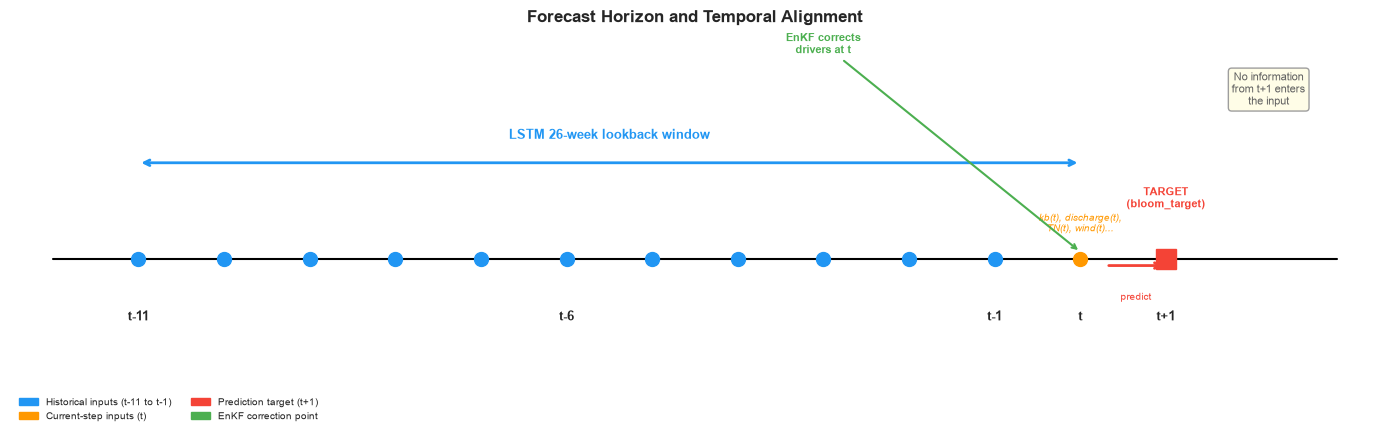


AUDIT COMPLETE


In [25]:
import matplotlib.patches as mpatches

def audit_forecast_horizon(test_df_unscaled, train_df_unscaled,
                           target_binary_col, target_col, bloom_threshold,
                           seq_len, forecast_horizon, feature_columns):
    """
    Audits the data pipeline for temporal alignment and potential leakage.
    Generates console diagnostics + a timeline figure for the manuscript.
    """
    print("=" * 70)
    print("FORECAST HORIZON AUDIT")
    print("=" * 70)

    df = test_df_unscaled.copy()

    # --- AUDIT 1: Target Alignment ---
    print("\n--- Audit 1: Target Alignment Check ---")
    print(f"  Forecast Horizon (pred_step): {forecast_horizon}")
    print(f"  Sequence Length:              {seq_len}")

    # In create_sequences_from_df:
    #   y[i] = data[i + seq_length + pred_step - 1, target_col_idx]
    # So for pred_step=1:
    #   y[i] = data[i + seq_length]  (one step AFTER the input window ends)
    #   Input window for sample i: rows [i, i+1, ..., i+seq_length-1]
    #   Last input row: i + seq_length - 1  (this is time t)
    #   Target row:     i + seq_length      (this is time t+1)

    if forecast_horizon == 1:
        print("\n  CONFIRMED: With pred_step=1, the sequence creator assigns:")
        print("    Input window: rows [i ... i+seq_len-1]  ->  weeks t-11 to t")
        print("    Target:       row  [i+seq_len]          ->  week t+1")
        print("  This is a genuine ONE-WEEK-AHEAD forecast. No leakage by construction.")
    else:
        print(f"\n  With pred_step={forecast_horizon}:")
        print(f"    Target is {forecast_horizon} step(s) ahead of the input window end.")

    # --- AUDIT 2: kb(t) vs bloom_target correlation ---
    print("\n--- Audit 2: Feature-Target Correlation ---")

    if target_col in df.columns and target_binary_col in df.columns:
        kb_vals = np.log1p(df[target_col].values)
        target_vals = df[target_binary_col].values

        corr_same = np.corrcoef(kb_vals, target_vals)[0, 1]
        print(f"  corr(log(kb[t]), bloom_target[t]):   {corr_same:.4f}")

        if len(df) > 1:
            corr_ahead = np.corrcoef(kb_vals[:-1], target_vals[1:])[0, 1]
            print(f"  corr(log(kb[t]), bloom_target[t+1]): {corr_ahead:.4f}")
        else:
            corr_ahead = np.nan

        print(f"\n  The LSTM uses kb(t) as input and predicts bloom_target(t+1).")
        print(f"  Since bloom_target is derived from kb >= {bloom_threshold:.0e},")
        print(f"  kb(t) is an autoregressive predictor of future bloom state.")
        print(f"  This is a one-step-lagged relationship, NOT leakage.")

        if corr_same > 0.95:
            print("\n  WARNING: Very high same-timestep correlation. Verify that")
            print("  create_sequences_from_df uses pred_step >= 1, not pred_step=0.")
    else:
        print(f"  Columns '{target_col}' or '{target_binary_col}' not found.")

    # --- AUDIT 3: Feature list check ---
    print("\n--- Audit 3: Feature Column Membership ---")
    if feature_columns is not None:
        if target_binary_col in feature_columns:
            print(f"  NOTE: '{target_binary_col}' IS in the feature list.")
            print(f"  This is expected — it's added back during sequence creation")
            print(f"  so that y can be extracted. The target index is identified")
            print(f"  and extracted as y, NOT fed as a regular input feature if")
            print(f"  the LSTM only sees the other columns.")
        else:
            print(f"  '{target_binary_col}' is NOT in the feature list (clean).")

        kb_features = [c for c in feature_columns if c.startswith('kb')]
        print(f"  K. brevis features in input: {kb_features}")
        print(f"  These are autoregressive predictors at lags t, L1, L2, etc.")
        print(f"  All are temporally valid for predicting bloom at t+1.")

    # --- GENERATE TIMELINE FIGURE ---
    print("\n--- Generating Timeline Diagram ---")
    fig, ax = plt.subplots(figsize=(14, 4.5))

    y_line = 0.5
    ax.plot([-12, 3], [y_line, y_line], 'k-', linewidth=1.5)

    for w in range(-11, 1):
        color = '#2196F3' if w < 0 else '#FF9800'
        ax.plot(w, y_line, 'o', color=color, markersize=10, zorder=5)

    for w, label in [(-11, 't-11'), (-6, 't-6'), (-1, 't-1'), (0, 't')]:
        ax.text(w, y_line - 0.18, label, ha='center', fontsize=9, fontweight='bold')

    ax.plot(1, y_line, 's', color='#F44336', markersize=14, zorder=5)
    ax.text(1, y_line - 0.18, 't+1', ha='center', fontsize=9, fontweight='bold')
    ax.text(1, y_line + 0.15, 'TARGET\n(bloom_target)', ha='center',
            fontsize=8, color='#F44336', fontweight='bold')

    ax.annotate('', xy=(-11, y_line + 0.28), xytext=(0, y_line + 0.28),
                arrowprops=dict(arrowstyle='<->', color='#2196F3', lw=2))
    ax.text(-5.5, y_line + 0.35, f'LSTM {seq_len}-week lookback window',
            ha='center', fontsize=9, color='#2196F3', fontweight='bold')

    ax.text(0, y_line + 0.08, 'kb(t), discharge(t),\nTN(t), wind(t)...',
            ha='center', fontsize=7, style='italic', color='#FF9800')

    ax.annotate('EnKF corrects\ndrivers at t',
                xy=(0, y_line + 0.02), xytext=(-3, y_line + 0.6),
                fontsize=8, ha='center', color='#4CAF50', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=1.5))

    ax.annotate('', xy=(1, y_line - 0.02), xytext=(0.3, y_line - 0.02),
                arrowprops=dict(arrowstyle='->', color='#F44336', lw=2))
    ax.text(0.65, y_line - 0.12, 'predict', ha='center', fontsize=7, color='#F44336')

    ax.text(2.2, y_line + 0.45, 'No information\nfrom t+1 enters\nthe input',
            ha='center', fontsize=8, color='#616161',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFDE7', edgecolor='#9E9E9E'))

    legend_elements = [
        mpatches.Patch(color='#2196F3', label='Historical inputs (t-11 to t-1)'),
        mpatches.Patch(color='#FF9800', label='Current-step inputs (t)'),
        mpatches.Patch(color='#F44336', label='Prediction target (t+1)'),
        mpatches.Patch(color='#4CAF50', label='EnKF correction point'),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=7, framealpha=0.9, ncol=2)

    ax.set_xlim(-12.5, 3.5)
    ax.set_ylim(0, 1.15)
    ax.axis('off')
    ax.set_title('Forecast Horizon and Temporal Alignment', fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()

    os.makedirs('output', exist_ok=True)
    plt.savefig('output/forecast_timeline_diagram.png', dpi=300, bbox_inches='tight')
    plt.savefig('output/forecast_timeline_diagram.pdf', bbox_inches='tight')
    print("  Saved: output/forecast_timeline_diagram.png / .pdf")
    plt.show()

    print("\n" + "=" * 70)
    print("AUDIT COMPLETE")
    print("=" * 70)


# --- Execute ---
if __name__ == "__main__":
    if 'test_df' in locals() and 'final_feature_columns_used' in locals():
        audit_forecast_horizon(
            test_df_unscaled=test_df,
            train_df_unscaled=train_df,
            target_binary_col=TARGET_BINARY_COL,
            target_col=TARGET_COL,
            bloom_threshold=BLOOM_THRESHOLD,
            seq_len=SEQUENCE_LENGTH,
            forecast_horizon=FORECAST_HORIZON,
            feature_columns=final_feature_columns_used
        )
    else:
        print("Error: Run Parts 1-6 first (need test_df, final_feature_columns_used).")

## Persist artifacts for downstream notebooks

This is the only cell that's new (not in the original notebook). It writes the
unscaled and scaled split dataframes to parquet so notebooks 02–07 don't need to
re-run the full preprocessing pipeline. The sequence `.npz`, scaler, and feature
list are already saved by Part 5/Part 6 above.

In [26]:
def enkf_preprocess_drivers_calibrated(df, state_vars, Q_base_diag, R_base_diag,
                                        kb_idx, alpha_kb, Q_kb_floor,
                                        Q_inflation, R_inflation,
                                        n_enkf=50, seed=42, append_std=False):
    """EnKF driver preprocessing with calibrated noise specifications.

    Drop-in replacement for enkf_preprocess_drivers. Applies:
      - state-dependent Q on the kb channel:
            Q_kb(t) = max(alpha_kb * x_kb(t-1)**2, Q_kb_floor)
      - per-channel Q inflation for non-kb channels:
            Q[j] = Q_inflation[j] * Q_base_diag[j]
      - per-channel R inflation for all channels:
            R[j] = R_inflation[j] * R_base_diag[j]
    """
    rng = np.random.default_rng(seed)
    obs = df[state_vars].values.astype(float)
    T, n = obs.shape

    Q_base = np.asarray(Q_base_diag, dtype=float)
    R_eff = np.asarray(R_inflation, dtype=float) * np.asarray(R_base_diag, dtype=float)
    R = np.diag(R_eff)

    valid_mask = ~np.any(np.isnan(obs), axis=1)
    if not valid_mask.any():
        raise ValueError("No valid observations to seed the ensemble.")
    first_valid_idx = int(np.argmax(valid_mask))
    x0 = obs[first_valid_idx]
    ensemble = x0[None, :] + rng.multivariate_normal(np.zeros(n), np.diag(Q_base), size=n_enkf)

    x_analysis = np.zeros((T, n))
    P_analysis_diag = np.zeros((T, n))

    for t in range(T):
        Q_diag_t = Q_inflation * Q_base
        if t == 0:
            Q_kb_t = Q_base[kb_idx]
        else:
            kb_prev = float(ensemble.mean(axis=0)[kb_idx])
            Q_kb_t = max(alpha_kb * kb_prev ** 2, Q_kb_floor)
        Q_diag_t[kb_idx] = Q_kb_t
        Q = np.diag(Q_diag_t)

        if t == 0:
            ens_f = ensemble.copy()
        else:
            w = rng.multivariate_normal(np.zeros(n), Q, size=n_enkf)
            ens_f = ensemble + w

        xf = ens_f.mean(axis=0)
        Pf = np.cov(ens_f.T) if n_enkf > 1 else np.zeros((n, n))

        y = obs[t]
        if np.any(np.isnan(y)):
            ens_a = ens_f
            xa = xf
            Pa = Pf
        else:
            S = Pf + R
            try:
                K = np.linalg.solve(S.T, Pf.T).T
            except np.linalg.LinAlgError:
                K = Pf @ np.linalg.pinv(S)
            v = rng.multivariate_normal(np.zeros(n), R, size=n_enkf)
            ens_a = ens_f + ((y[None, :] + v) - ens_f) @ K.T
            xa = ens_a.mean(axis=0)
            Pa = np.cov(ens_a.T) if n_enkf > 1 else np.zeros((n, n))

        x_analysis[t] = xa
        P_analysis_diag[t] = np.diag(Pa)
        ensemble = ens_a

    df_out = df.copy()
    for j, var in enumerate(state_vars):
        df_out[var] = x_analysis[:, j]
    if append_std:
        for j, var in enumerate(state_vars):
            df_out[f"{var}_enkf_std"] = np.sqrt(P_analysis_diag[:, j])
    return df_out

In [27]:
import json
json.dump([str(c) for c in x_feature_columns], open("output_refactored/intermediate/feature_names.json", "w"))

In [28]:
# --- Persist raw artifacts and build the configured EnKF-preprocessed branch ---
from data_pipeline_utils import add_onset_feature_columns
from enkf_utils import estimate_enkf_noise, enkf_preprocess_drivers_with_propagator
from pipeline_utils import build_sequence_artifact, write_json
from propagators import fit_all_propagators, summarize_propagators

# Raw branch from the existing feature-engineering/scaling cells.
train_df.to_parquet(TRAIN_DF_PATH)
validation_df.to_parquet(VAL_DF_PATH)
test_df.to_parquet(TEST_DF_PATH)
train_scaled_df.to_parquet(TRAIN_SCALED_PATH)
validation_scaled_df.to_parquet(VAL_SCALED_PATH)
test_scaled_df.to_parquet(TEST_SCALED_PATH)
print(f"Saved raw split artifacts to {INTERMEDIATE_DIR}")

# Re-save the raw default sequence artifact with explicit metadata. This keeps
# notebook 01 useful even before notebook 02 chooses the tuned sequence length.
raw_sequences = build_sequence_artifact(
    train_scaled_df, validation_scaled_df, test_scaled_df,
    final_feature_columns_used, TARGET_BINARY_COL,
    SEQUENCE_LENGTH, FORECAST_HORIZON, RAW_SEQUENCES_PATH,
)
print(f"Saved raw default sequences: {RAW_SEQUENCES_PATH}")

# EnKF preprocessing is applied before onset-derived and lag/rolling feature
# engineering. Use df_initial_raw from Part 2b so the filtered branch does not
# inherit raw-driver rate/anomaly columns.
enkf_source_df = df_initial_raw.copy() if 'df_initial_raw' in globals() and df_initial_raw is not None else df_initial.copy()
state_vars_present = [
    v for v in ENKF_PREPROCESS_STATE_VARS
    if v in train_df.columns and v in enkf_source_df.columns
]
if not state_vars_present:
    raise ValueError("No ENKF_PREPROCESS_STATE_VARS are present in the input dataframe.")

# R is estimated from the raw training split once. The selected propagator owns
# the forecast-step dynamics and its fitted residual covariance Q.
Q_reference_diag, R_diag = estimate_enkf_noise(
    train_df,
    state_vars_present,
    obs_noise_frac=ENKF_OBS_NOISE_FRAC,
    proc_noise_frac=ENKF_PROC_NOISE_FRAC,
    protect_vars=ENKF_PROTECT_VARS,
    protect_obs_frac=ENKF_PROTECT_OBS_FRAC,
)

fitted_propagators = fit_all_propagators(
    train_df,
    state_vars_present,
    manual_q_diag=None,
    seasonal_n_harmonics=ENKF_SEASONAL_N_HARMONICS,
)
if ENKF_PREPROCESSOR_PROPAGATOR not in fitted_propagators:
    raise KeyError(
        f"Configured ENKF_PREPROCESSOR_PROPAGATOR={ENKF_PREPROCESSOR_PROPAGATOR!r} "
        f"not found in fitted propagators: {list(fitted_propagators)}"
    )
selected_propagator = fitted_propagators[ENKF_PREPROCESSOR_PROPAGATOR]
Q_matrix = np.asarray(selected_propagator.Q, dtype=float)
Q_diag = np.diag(Q_matrix).astype(float).tolist()

print(f"Configured EnKF propagator: {ENKF_PREPROCESSOR_PROPAGATOR}")
print(f"  Q trace from fitted propagator: {np.trace(Q_matrix):.6e}")
print("  R diag from notebook-01 policy:")
for var, r in zip(state_vars_present, R_diag):
    print(f"    {var:20s} {r:.6g}")

prop_summary = summarize_propagators(fitted_propagators)
print("\nFitted propagator summary:")
display(prop_summary)

df_initial_enkf_base = enkf_preprocess_drivers_with_propagator(
    enkf_source_df,
    state_vars=state_vars_present,
    propagator=selected_propagator,
    R_diag=R_diag,
    Q_matrix=Q_matrix,
    n_enkf=N_ENKF,
    seed=SEED,
    append_std=ENKF_APPEND_STD_FEATURES,
)

# Recompute onset-derived columns after replacing the driver states so rate,
# anomaly, alongshore-wind, and weeks-since-bloom features match this branch.
df_initial_enkf = add_onset_feature_columns(df_initial_enkf_base, TARGET_BINARY_COL)

df_processed_enkf = create_features(
    df_initial_enkf,
    TARGET_COL,
    TARGET_BINARY_COL,
    BASE_FEATURES,
    use_enhanced=USE_ENHANCED_FEATURES,
    basic_cfg=BASIC_LAG_CONFIG,
    enhanced_cfg=ENHANCED_LAG_CONFIG,
)

enkf_train_df, enkf_validation_df, enkf_test_df = split_data_chronological(
    df_processed_enkf, TRAIN_SPLIT_RATIO, VALIDATION_SPLIT_RATIO
)

enkf_scaler_template = ENKF_SCALER_FILENAME.replace(f"{scaler_suffix}_enkf", "{}_enkf")
enkf_flist_template = ENKF_FEATURE_LIST_FILENAME.replace(f"{feature_suffix}_enkf", "{}_enkf")
(
    enkf_train_scaled_df,
    enkf_validation_scaled_df,
    enkf_test_scaled_df,
    enkf_scaler,
    enkf_feature_columns,
) = preprocess_data(
    enkf_train_df,
    enkf_validation_df,
    enkf_test_df,
    TARGET_BINARY_COL,
    scaler_type=SCALER_TYPE,
    output_dir=OUTPUT_DIR,
    scaler_fname_template=enkf_scaler_template,
    flist_fname_template=enkf_flist_template,
    feature_suffix=feature_suffix,
)

enkf_train_df.to_parquet(ENKF_TRAIN_DF_PATH)
enkf_validation_df.to_parquet(ENKF_VAL_DF_PATH)
enkf_test_df.to_parquet(ENKF_TEST_DF_PATH)
enkf_train_scaled_df.to_parquet(ENKF_TRAIN_SCALED_PATH)
enkf_validation_scaled_df.to_parquet(ENKF_VAL_SCALED_PATH)
enkf_test_scaled_df.to_parquet(ENKF_TEST_SCALED_PATH)

enkf_sequences = build_sequence_artifact(
    enkf_train_scaled_df, enkf_validation_scaled_df, enkf_test_scaled_df,
    enkf_feature_columns, TARGET_BINARY_COL,
    SEQUENCE_LENGTH, FORECAST_HORIZON, ENKF_SEQUENCES_PATH,
)

_noise_meta = {
    "state_vars": state_vars_present,
    "propagator": ENKF_PREPROCESSOR_PROPAGATOR,
    "propagator_selection_reason": "Selected as main EnKF propagator after notebook 03a fair comparison favored SeasonalAR1 for Brier/AUC/AUPRC/onset detection.",
    "Q_reference_diag_from_noise_policy": Q_reference_diag,
    "Q_diag": Q_diag,
    "Q_matrix": Q_matrix.tolist(),
    "Q_trace": float(np.trace(Q_matrix)),
    "R_diag": R_diag,
    "n_enkf": N_ENKF,
    "obs_noise_frac": ENKF_OBS_NOISE_FRAC,
    "proc_noise_frac": ENKF_PROC_NOISE_FRAC,
    "protect_vars": ENKF_PROTECT_VARS,
    "protect_obs_frac": ENKF_PROTECT_OBS_FRAC,
    "append_std": ENKF_APPEND_STD_FEATURES,
    "propagator_summary": prop_summary.to_dict(orient="records"),
    "enkf_calibration_used": False,
}
if hasattr(selected_propagator, "n_harmonics"):
    _noise_meta["seasonal_n_harmonics"] = int(selected_propagator.n_harmonics)
if hasattr(selected_propagator, "alpha") and selected_propagator.alpha is not None:
    _noise_meta["propagator_alpha"] = np.asarray(selected_propagator.alpha, dtype=float).tolist()
if hasattr(selected_propagator, "spectral_radius") and selected_propagator.spectral_radius is not None:
    _noise_meta["spectral_radius"] = float(selected_propagator.spectral_radius)

write_json(ENKF_PREPROCESSOR_NOISE_PATH, _noise_meta)

print(f"Saved EnKF-preprocessed split artifacts to {INTERMEDIATE_DIR}")
print(f"Saved EnKF default sequences: {ENKF_SEQUENCES_PATH}")
print(f"Saved EnKF noise/propagator metadata: {ENKF_PREPROCESSOR_NOISE_PATH}")

print(f"\nFinal pipeline artifacts in {INTERMEDIATE_DIR}:")
for f in sorted(os.listdir(INTERMEDIATE_DIR)):
    print(f"  {f}")

Saved raw split artifacts to output_refactored/intermediate
Saved raw default sequences: output_refactored/sequences_horizon1wk_enhanced.npz
Configured EnKF propagator: SeasonalAR1
  Q trace from fitted propagator: 5.978210e+13
  R diag from notebook-01 policy:
    peace_discharge      1.03362e+06
    peace_TN             2.0018
    peace_TP             0.167676
    kb                   1.26558e+12
    wind_u               9.63805
    wind_v               14.1038

Fitted propagator summary:


,propagator,Q_trace,Q_diag_geomean,alpha[peace_discharge],alpha[peace_TN],alpha[peace_TP],alpha[kb],alpha[wind_u],alpha[wind_v],VAR1_spectral_radius
0,RandomWalk,9.773668e+13,11129.480289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AR1,6.003013e+13,7883.858517,0.804807,0.697117,0.730013,0.228405,0.114317,0.114984,NaN
2,VAR1,5.960916e+13,7844.372271,NaN,NaN,NaN,NaN,NaN,NaN,0.807573
3,SeasonalAR1,5.978210e+13,7720.671734,0.777907,0.684238,0.717253,0.223399,0.087198,0.057036,NaN


EnKF Initialized. Members: 50, State Dim: 6

--- Creating Features (Enhanced Mode: True) ---
Using ENHANCED feature configuration.
Creating lagged features for target: kb...
  Created KB weekly lags: L1, L2
Creating rolling aggregate features for KB...
  Created approx KB monthly lags (mean, prop_bloom): M1, M2, M3
Creating rolling average feature for peace_discharge...
  Created peace_discharge_4w_avg_L1

Creating lagged environmental/hydrological features...
  Lagged features created for: zos, water_temp, peace_discharge, peace_TN, peace_TP, wind_u, wind_v, wind_alongshore using lags L1

Maximum lag/window introduced: 12 weeks.
Dropped first 12 rows due to NaNs generated by feature engineering.
Shape after dropping initial NaNs: (1605, 59)

--- Feature Engineering Complete ---
Final number of columns (features + targets): 59

--- Splitting Data into Train, Validation, and Test Sets (Chronological) ---
Total samples: 1605
Training set:   1123 samples (Index: 1993-03-29 00:00:00 to 201